# Wall-to-Wall Land Cover Maps: Forested Ecoregions of Oregon

Applies the tuned XGBoost model trained in [Main.ipynb](Main.ipynb) to produce full-coverage GLanCE Level-1 land cover maps (Water, Ice/Snow, Developed, Barren/Sparse, Trees, Shrubs, Herbaceous) for 2019 and 2025, restricted to the forested ecoregions of Oregon.

#### Scope: Oregon forest ecoregions, glaciers excluded

This run is scoped to Oregon only (`state_names = ['Oregon']`), a first slice of the eventual Washington plus Oregon job. Prediction is limited to the hand-picked RESOLVE Ecoregions 2017 forest ecoregions (`Map_Export.FOREST_ECOREGIONS`) clipped to the Oregon boundary: the Temperate Conifer Forests ecoregions that reach into Oregon (Coast Range, Cascades, Eastern Cascades, Klamath-Siskiyou, Blue Mountains), plus the Willamette Valley oak savanna. The Willamette is included by explicit choice even though RESOLVE classes it as grassland or savanna, so remember that when interpreting its class mix. Ecoregions that sit entirely in Washington (for example Puget lowland forests, North Cascades conifer forests) simply contribute zero area here.

Permanent ice is masked out using GLIMS glacier outlines (Step 1b). The model has no Ice/Snow class, because GLanCE's North America training data contains none, so every glaciated pixel would otherwise be silently misclassified as Trees, Barren, or Shrubs. Oregon's glaciers (Hood, Jefferson, the Three Sisters) are small, about 4,300 ha inside the AOI, but masking them is the honest fix.

#### Years, and a caveat on 2025

GLanCE labels only run through 2021, so the model's point-validated accuracy is established for 2017 to 2021 only. 2019 falls inside that validated range. 2025 is out-of-sample extrapolation: AlphaEarth embeddings exist for it, but there is no contemporaneous ground truth to check the map against. Treat the 2025 map as exploratory and say so in any write-up.

#### Why the heavy work happens in the cloud

The Oregon forest AOI is roughly 1.7 billion 10 m pixels; at 64 float32 bands that is about 0.44 TB of raw embeddings per year. Rather than pull that down to a 16 GB laptop, the embeddings are exported to Cloud Storage, scored by the same saved model on a temporary Compute Engine VM in the bucket's region (GCS to VM traffic is free), and only the much smaller predicted-class rasters come back.

Pipeline: Step 1 AOI, Step 1b glacier mask, Step 2 export embeddings, Step 3 VM inference (runs outside this notebook), Step 4 mosaic and clip, Step 5 visualize, Step 6 cost cleanup.

## Setup

In [11]:
%load_ext autoreload
%autoreload 2

# ── Load libraries and functions ────────────────────────────────────────────────────────────
import os

import ee
import geemap

from Constants import MODEL_DIR
from Glance_Class_Definitions import class1_dict
from Geo_Utils import get_wa_or_geometry
from Map_Export import (
    EXCLUDED_ECOREGIONS,
    FOREST_ECOREGIONS,
    export_embeddings_to_gcs,
    get_embedding_image,
    get_forest_aoi,
    get_forest_ecoregion_fc,
    get_glacier_fc,
    list_ecoregions,
    wait_for_tasks,
)

# ── Initiate GEE Project ────────────────────────────────────────────────────────────────────
ee.Initialize(project='turnkey-lacing-391919')

# ── Define Variables ────────────────────────────────────────────────────────────────────────
state_names = ['Oregon']    # this run is Oregon only; use ['Oregon', 'Washington'] for the full job
years = [2025]#[2019, 2025]        # 2019 is inside the GLanCE-validated range; 2025 is extrapolation
exclude_glaciers = True     # mask permanent ice (the model has no Ice/Snow class)
gcs_bucket = 'turnkey-lacing-391919-lulc'      # exports land here
gcs_prefix = 'wall_to_wall/oregon/embeddings'  # distinct from the pilot's 'pilot/embeddings'
model_path = os.path.join(MODEL_DIR, 'XGBoost_tuned_model_groupedCV.joblib')
map_dir = os.path.join('Data', 'Maps', 'oregon')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Step 1: Area of interest (forest ecoregions of Oregon)

The AOI is the union of the hand-picked `FOREST_ECOREGIONS`, intersected with the Oregon boundary. The first cell lists every RESOLVE ecoregion touching Oregon so the include and exclude call is visible and auditable, and so the exact `ECO_NAME` strings can be read off the dataset. That matters: the names are inconsistently capitalized (`'Central-Southern Cascades Forests'` vs `'... forests'`) and `ee.Filter.inList` matches exactly, so a name typed from memory would silently drop a whole ecoregion instead of erroring.

In [12]:
# ── RESOLVE ecoregions intersecting Oregon ──────────────────────────────────────────────────
# Edit Map_Export.FOREST_ECOREGIONS from this table, not from memory.
oregon_geometry = get_wa_or_geometry(state_names=state_names)
ecoregions = list_ecoregions(geometry=oregon_geometry)
print(f'{int(ecoregions["included"].sum())} of {len(ecoregions)} ecoregions included in the Oregon forest AOI\n')
display(ecoregions)

print('\nExcluded as naturally non-forest:')
for name in EXCLUDED_ECOREGIONS:
    print(f'  - {name}')

9 of 11 ecoregions included in the Oregon forest AOI



,BIOME_NAME,ECO_NAME,included
0,Deserts & Xeric Shrublands,Snake-Columbia shrub steppe,False
1,Temperate Conifer Forests,Blue Mountains forests,True
2,Temperate Conifer Forests,Central Pacific Northwest coastal forests,True
3,Temperate Conifer Forests,Central-Southern Cascades Forests,True
4,Temperate Conifer Forests,Eastern Cascades forests,True
5,Temperate Conifer Forests,Great Basin montane forests,True
6,Temperate Conifer Forests,Klamath-Siskiyou forests,True
7,Temperate Conifer Forests,Northern California coastal forests,True
8,Temperate Conifer Forests,Puget lowland forests,True
9,"Temperate Grasslands, Savannas & Shrublands",Palouse prairie,False



Excluded as naturally non-forest:
  - Snake-Columbia shrub steppe
  - Palouse prairie


In [13]:
# ── Build the forest AOI (FOREST_ECOREGIONS ∩ Oregon, glaciers excluded) ─────────────────────
forest_geometry, forest_mask = get_forest_aoi(state_names=state_names, exclude_glaciers=exclude_glaciers)

# ── Report the area, which sets the export size and therefore the cost ──────────────────────
state_km2 = get_wa_or_geometry(state_names=state_names).area(maxError=100).divide(1e6).getInfo()
forest_km2 = forest_geometry.area(maxError=100).divide(1e6).getInfo()
n_pixels = forest_km2 * 1e6 / 100  # 10 m pixels

print(f'Oregon area     : {state_km2:>12,.0f} km2')
print(f'Forest AOI area : {forest_km2:>12,.0f} km2  ({forest_km2 / state_km2:.1%} of Oregon)')
print(f'10 m pixels     : {n_pixels / 1e9:>12.2f} billion')
print(f'Raw embeddings  : {n_pixels * 64 * 4 / 1e12:>12.2f} TB/year uncompressed (64 bands x float32)')
print('(Area is the forest geometry; the small glacier area removed by the mask is reported in Step 1b.)')

Oregon area     :      254,297 km2
Forest AOI area :      171,329 km2  (67.4% of Oregon)
10 m pixels     :         1.71 billion
Raw embeddings  :         0.44 TB/year uncompressed (64 bands x float32)
(Area is the forest geometry; the small glacier area removed by the mask is reported in Step 1b.)


## Step 1b: Mask out glaciers

The tuned model's `classes_` is `[1, 3, 4, 5, 6, 7]`: there is no Ice/Snow class, because GLanCE's North America training data contains none. Left in, every permanent-ice pixel on Oregon's glaciated peaks would be silently forced into Trees, Barren, or Shrubs, and a seasonal-snow pixel that melts between 2019 and 2025 could even register as spurious change. `get_forest_aoi(exclude_glaciers=True)` paints the GLIMS glacier outlines out of the mask, so those pixels become nodata, the same treatment as non-forest.

GLIMS is a fixed snapshot and PNW glaciers have retreated since capture, so the mask slightly over-covers current ice. That is the safe direction: it drops a few forest-edge pixels rather than keeping misclassified ice.

In [14]:
# ── How much ice did the mask remove? (sanity check) ────────────────────────────────────────
# Count glacier polygons and sum their per-polygon areas. This SUM slightly over-counts the
# actual masked area (~4,300 ha) because adjacent GLIMS polygons share edges; the true masked
# extent is their union. Either way it is a tiny fraction of the AOI. No dissolve needed here.
glacier_fc = get_glacier_fc(forest_geometry)
n_glaciers = glacier_fc.size().getInfo()
glacier_ha_sum = (glacier_fc.map(lambda f: f.set('ha', f.area(maxError=30).divide(1e4)))
                  .aggregate_sum('ha').getInfo())
print(f'GLIMS glacier polygons in the Oregon forest AOI: {n_glaciers}')
print(f'Summed polygon area (upper bound on masked area): {glacier_ha_sum:,.0f} ha '
      f'(~{glacier_ha_sum / (forest_km2 * 100):.3%} of the AOI; true union ~4,300 ha)')
print('Expect the ice on Hood, Jefferson, and the Three Sisters. Washington peaks (Rainier, '
      'Baker, Adams) should NOT appear -- this run is clipped to Oregon.')

GLIMS glacier polygons in the Oregon forest AOI: 427
Summed polygon area (upper bound on masked area): 5,690 ha (~0.033% of the AOI; true union ~4,300 ha)
Expect the ice on Hood, Jefferson, and the Three Sisters. Washington peaks (Rainier, Baker, Adams) should NOT appear -- this run is clipped to Oregon.


In [15]:
# ── Visualize the AOI, coloured by ecoregion, with glacier holes ─────────────────────────────
# Sanity checks: the eastern edge should follow the Cascades / shrub-steppe transition rather
# than the state line, the Willamette Valley (a savanna biome, included by choice) should show
# as its own polygon in western Oregon, and the glaciated peaks should read as red holes.

# One colour per FOREST_ECOREGIONS entry (ColorBrewer 'Paired', a qualitative palette; these
# are categories, so the colours carry no ordering).
eco_palette = [
    '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c',
    '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#b15928', '#8c564b',
]
assert len(eco_palette) >= len(FOREST_ECOREGIONS), 'need at least one colour per ecoregion'
eco_palette = eco_palette[:len(FOREST_ECOREGIONS)]

# ── Paint each polygon with its index in FOREST_ECOREGIONS, so palette order matches ────────
# Restrict to the Oregon AOI (forest_geometry is already clipped to Oregon).
eco_names = ee.List(FOREST_ECOREGIONS)
eco_fc = get_forest_ecoregion_fc().map(
    lambda f: f.set('eco_idx', eco_names.indexOf(f.get('ECO_NAME'))))
eco_image = ee.Image().byte().paint(eco_fc, 'eco_idx').clip(forest_geometry)

# ── Draw ────────────────────────────────────────────────────────────────────────────────────
aoi_map = geemap.Map(center=[44.0, -121.5], zoom=6)
aoi_map.addLayer(
    eco_image,
    {'min': 0, 'max': len(FOREST_ECOREGIONS) - 1, 'palette': eco_palette},
    'Forest ecoregions')
aoi_map.addLayer(
    ee.Image().byte().paint(eco_fc, 0, 1), {'palette': ['#333333']}, 'Ecoregion boundaries')
aoi_map.addLayer(
    ee.Image().byte().paint(get_glacier_fc(forest_geometry), 0, 2),
    {'palette': ['#e31a1c']}, 'Glaciers (masked out)')
aoi_map.addLayer(
    ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(get_wa_or_geometry(state_names=state_names))]), 0, 2),
    {'palette': ['#000000']}, 'Oregon boundary')
aoi_map.add_legend(title='Ecoregion', legend_dict=dict(zip(FOREST_ECOREGIONS, eco_palette)))
aoi_map

Map(center=[44.0, -121.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## Step 2: Export AlphaEarth embeddings to Cloud Storage

One export task per year, each writing forest-masked, glacier-masked 64-band GeoTIFF tiles to `gs://{bucket}/{prefix}/{year}/`. The bucket and prefix are set in the Setup cell (`gcs_bucket`, `gcs_prefix`); the prefix is `wall_to_wall/oregon/embeddings`, kept distinct from the pilot's `pilot/embeddings` so the two runs never collide.

The image is `.select(EMBEDDING_BANDS)`, pinning band order to `A00` through `A63`, the order the model was trained on. A silent reorder here would corrupt every prediction while still producing a plausible-looking map. `crs='EPSG:5070'` (NAD83 CONUS Albers Equal-Area) gives true 10 m pixels across Oregon; exporting in EPSG:4326 would distort them at this latitude. `fileDimensions=1024` keeps each tile about 268 MB uncompressed; 2048 would push past 1 GB per tile. Non-forest and glacier pixels are masked out, so they are never exported or classified.

These are large exports: budget well over an hour per year and expect a few thousand tiles per year. The next cell submits the tasks; run it when you are ready to start the export.

In [16]:
# ── Submit one export task per year ─────────────────────────────────────────────────────────
# Run this cell when you are ready to start the export. Tasks run server-side; you can close
# the notebook and poll later (next cell). Each task is named oregon_embeddings_{year} so it is
# easy to find in the Earth Engine Tasks tab and does not clash with the pilot's task names.
assert gcs_bucket, 'Set gcs_bucket in the Setup cell before exporting.'

tasks = []
for year in years:
    task = export_embeddings_to_gcs(
        year, forest_geometry, forest_mask, bucket=gcs_bucket, prefix=gcs_prefix,
        description=f'oregon_embeddings_{year}')
    tasks.append(task)
    print(f'submitted {year}: task {task.id} -> gs://{gcs_bucket}/{gcs_prefix}/{year}/')

submitted 2025: task 5MDZXQFXQFNVUDIZKBPXXVIM -> gs://turnkey-lacing-391919-lulc/wall_to_wall/oregon/embeddings/2025/


In [8]:
# ── Poll until every export reaches a terminal state ────────────────────────────────────────
# Safe to interrupt and re-run: the tasks keep running server-side regardless.
final_states = wait_for_tasks(tasks, poll_seconds=120)
print()
for description, state in final_states.items():
    print(f'{description}: {state}')

[15:37:39] oregon_embeddings_2019: COMPLETED

oregon_embeddings_2019: COMPLETED


## Step 3: Cloud VM inference (runs outside this notebook)

Not a notebook step: running it here would mean downloading about 0.44 TB/year. Instead, `vm_predict.py` runs on a temporary Compute Engine VM in the bucket's region, where GCS to VM traffic is free.

1. Provision a modest VM (for example `e2-standard-4`) in the bucket's region. It only holds one tile at a time.
2. Install `rasterio`, `xgboost`, `scikit-learn`, `google-cloud-storage`, pinned to the versions used locally. XGBoost version skew between training and inference can silently change predictions.
3. Copy up `XGBoost_tuned_model_groupedCV.joblib` plus [Tree_Ensemble.py](Tree_Ensemble.py). The pickled model's `_LabelDecodingClassifier` wrapper must be importable to unpickle.
4. Per tile (download, predict, discard, never more than one in memory): read 64 bands, reshape to `(H*W, 64)`, build a DataFrame with columns `A00` through `A63` in that exact order, mask nodata and edge pixels, `model.predict(...)` (the wrapper already returns Level-1 labels 1 to 7), reshape to `(H, W)`, write a compressed single-band `uint8` GeoTIFF with nodata distinct from the 1 to 7 class values, upload to `.../predictions/`.
5. Delete the VM once the year's tiles are done. Required, not optional cleanup.

`vm_predict.py` is not written yet. It is the next step after the exports land.

## Step 4: Mosaic and clip (local)

Once the small prediction tiles are in `gs://{bucket}/{prefix}/../predictions/{year}/`:

- Download only the `predictions/` tiles (about 256x smaller than the embeddings, cheap to pull).
- `rasterio.merge.merge()` the tiles into one annual mosaic.
- `rasterio.mask.mask()` against `forest_geometry` (reprojected to EPSG:5070), a belt-and-suspenders clip on top of the export-time mask, guaranteeing a clean forest-only footprint.
- Save to `Data/Maps/oregon/LULC_Class1_forest_{year}.tif`.

In [ ]:
# ── Step 4a: download prediction + confidence tiles and mosaic each into one raster ──────────
# The mosaic is memory-safe (streams tiles into the output one at a time); see
# Map_Postprocess.mosaic_tiles. Run Setup first; Step 1 is not needed for 4a.
import glob
import subprocess

from Map_Postprocess import mosaic_tiles

download_predicted_tiles = True                 # set False to reuse tiles already in map_dir
gcs_run_root = gcs_prefix.rsplit('/', 1)[0]      # '.../oregon'; predictions/confidence are siblings of embeddings
os.makedirs(map_dir, exist_ok=True)

mosaics = {}                                     # year -> class mosaic path (input to Step 4b)
for year in years:
    for kind, label in [('predictions', 'LULC_Class1_forest'), ('confidence', 'confidence')]:
        local_dir = os.path.join(map_dir, f'{kind}_{year}')
        os.makedirs(local_dir, exist_ok=True)
        if download_predicted_tiles:
            src = f'gs://{gcs_bucket}/{gcs_run_root}/{kind}/{year}/*.tif'
            # gcloud storage cp (not gsutil) -- faster and avoids gsutil hangs on newer Python.
            subprocess.run(['gcloud', 'storage', 'cp', src, local_dir + '/'], check=True)
        tifs = sorted(glob.glob(os.path.join(local_dir, '*.tif')))
        if not tifs:
            print(f'{year} {kind}: no tiles under {local_dir} (inference not done for this year?) -- skipping')
            continue
        out = os.path.join(map_dir, f'{label}_{year}_mosaic.tif')
        _, shape = mosaic_tiles(tifs, out)
        if kind == 'predictions':
            mosaics[year] = out
        print(f'{year} {kind}: mosaicked {len(tifs)} tiles -> {out}  {shape}')

In [ ]:
# ── Step 4b (optional): clip each class mosaic to the forest geometry ────────────────────────
# Belt-and-suspenders only: the embeddings were exported with updateMask(forest_mask) (forest
# ecoregions minus glaciers), so each mosaic is ALREADY forest-only with 255 elsewhere. This
# re-clips to forest_geometry (Step 1) as a guarantee, and prints the class mix as a sanity
# check. It reads each full mosaic into RAM (a few GB for a state-sized raster), so skip it if
# memory is tight -- the export-time mask already gives a clean footprint. Requires Step 1.
import geopandas as gpd
import rasterio.mask
from shapely.geometry import shape

# forest_geometry (ee.Geometry, EPSG:4326) -> local polygon in the mosaic CRS (EPSG:5070).
# The getInfo() on Oregon's dissolved forest geometry can take a moment (many vertices).
forest_gdf = gpd.GeoDataFrame(
    geometry=[shape(forest_geometry.getInfo())], crs='EPSG:4326').to_crs('EPSG:5070')

for year, path in mosaics.items():
    with rasterio.open(path) as src:
        clipped, transform = rasterio.mask.mask(src, forest_gdf.geometry, nodata=255, filled=True)
        profile = src.profile
        profile.update(height=clipped.shape[1], width=clipped.shape[2], transform=transform)
    out = os.path.join(map_dir, f'LULC_Class1_forest_{year}.tif')
    with rasterio.open(out, 'w', **profile) as dst:
        dst.write(clipped)
    valid = clipped[0] != 255
    uniq, cnt = np.unique(clipped[0][valid], return_counts=True)
    mix = ', '.join(f'{class1_dict.get(int(u), u)} {c / valid.sum():.0%}'
                    for u, c in sorted(zip(uniq, cnt), key=lambda x: -x[1]))
    print(f'{year}: clipped -> {out}')
    print(f'   valid pixels: {int(valid.sum()):,} | class mix (expect Trees-dominated): {mix}')

## Step 5: Visualize and sanity-check

- Render each map with a categorical colormap keyed to `class1_dict`.
- Expect Trees to dominate: the AOI is forest ecoregions, so the mix should be mostly Trees with smaller amounts of Water, Developed, and Herbaceous (openings and clearcuts), and little Shrubs or Barren. A map that is mostly Shrubs or Herbaceous signals a pipeline bug (band mis-ordering, or the mask applied to the wrong geometry) rather than model error.
- Confirm the nodata edges follow the RESOLVE forest polygons, not the state line, and that the glaciated peaks read as nodata holes.
- Compare 2019 vs 2025 for implausible wholesale class flips.


2019: 21,572,490 ha mapped
  Trees            12,814,757 ha  (59.4%)
  Herbaceous        3,956,973 ha  (18.3%)
  Shrubs            3,785,767 ha  (17.5%)
  Barren/Sparse       405,345 ha  (1.9%)
  Developed           395,283 ha  (1.8%)
  Water               214,365 ha  (1.0%)
  -> Trees = 59% of the AOI (OK, Trees-dominated as expected)


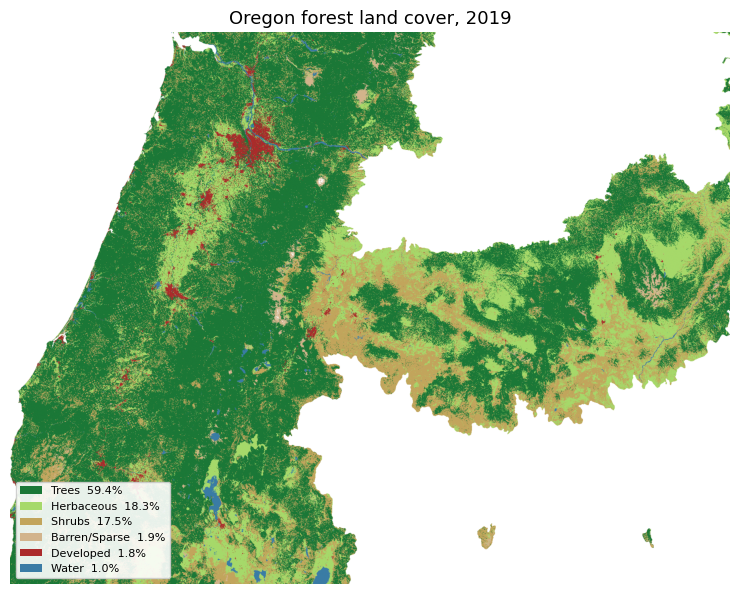

In [10]:
# ── Step 5: visualize the map + class-area sanity check ──────────────────────────────────────
# Uses whichever map Step 4 produced (clipped LULC_Class1_forest_{year}.tif if Step 4b ran,
# else the _mosaic.tif from Step 4a). Class areas and the overview are both memory-safe; see
# Map_Postprocess (class_areas reads block-by-block, overview_rgb reads a decimated overview).
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from Map_Postprocess import CLASS_COLORS, class_areas, find_map, overview_rgb

maps = [(y, find_map(map_dir, y)) for y in years]
maps = [(y, p) for y, p in maps if p]
if not maps:
    print('No map found in', map_dir, '-- run Step 4 first.')
else:
    fig, axes = plt.subplots(1, len(maps), figsize=(7.5 * len(maps), 9), squeeze=False)
    for ax, (year, path) in zip(axes[0], maps):
        areas = class_areas(path)
        total = sum(areas.values())
        ax.imshow(overview_rgb(path))
        ax.set_title(f'Oregon forest land cover, {year}', fontsize=13)
        ax.axis('off')
        present = sorted(areas, key=areas.get, reverse=True)
        ax.legend(handles=[Patch(facecolor=CLASS_COLORS.get(c, '#000'),
                                 label=f'{class1_dict.get(c, c)}  {areas[c] / total:.1%}')
                           for c in present],
                  loc='lower left', fontsize=8, framealpha=0.9)
        print(f'\n{year}: {total:,.0f} ha mapped')
        for c in present:
            print(f'  {class1_dict.get(c, c):<14} {areas[c]:>12,.0f} ha  ({areas[c] / total:.1%})')
        trees_frac = areas.get(5, 0) / total
        print(f'  -> Trees = {trees_frac:.0%} of the AOI '
              f'({"OK, Trees-dominated as expected" if trees_frac > 0.5 else "LOW -- check for a band-order / mask bug"})')
        if 2 in areas:
            print('  -> WARNING: Ice/Snow (id 2) present, but the model cannot predict it -- check the glacier mask.')
    plt.tight_layout()
    plt.show()

## Step 6: Cost control checklist (every run)

- [ ] Compute Engine VM deleted after each year's tiles are processed.
- [ ] Raw embedding tiles in GCS (the large pre-prediction files, about 0.44 TB/year) deleted once the prediction tiles are safely uploaded.
- [ ] Only the small `predictions/` tiles and the final local mosaics kept long-term.

Earth Engine compute itself is free on a noncommercial project; the cost here is VM time plus brief GCS storage (roughly a few dollars for Oregon's two years), less than the full WA plus OR job and far less than pulling the raw embeddings to the laptop.